In [41]:
!pip install -q tensorflow tensorflowjs scikit-learn imbalanced-learn xgboost pandas matplotlib seaborn

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
print(f"TF: {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

TF: 2.19.0, GPU: []


In [43]:
np.random.seed(42)

# ========== DIAGNOSIS-FIRST APPROACH ==========
# Tentukan diagnosis DULU, baru generate fitur sesuai profil klinis
# Ini menciptakan pola yang jelas dan realistis untuk model belajar

classes = ['Normal', 'GERD Ringan', 'GERD Sedang', 'GERD Berat', 'Komplikasi']
samples_per_class = [2400, 2400, 2400, 2400, 2400]  # 12000 total, seimbang

# Profil klinis per diagnosis (mean untuk setiap fitur)
# Format: [heartburn, regurgitasi, merokok, alkohol, waktu_mk_tidur, nsaid, stres,
#          riwayat_kel, kafein, mkn_pedas, mkn_berlemak, posisi_tidur, batuk_kronis,
#          usia, jenis_kelamin, aktivitas_fisik, minum_soda, kualitas_tidur,
#          bmi, ph_esofagus, demeester, hernia_hiatal, tekanan_les, grade_esofagitis,
#          h_pylori, kadar_gastrin]

profiles = {
    'Normal': {
        'heartburn': (0.3, 0.5), 'regurgitasi': (0.2, 0.4),
        'merokok': (0.5, 0.8), 'alkohol': (0.4, 0.6), 'waktu_mk_tidur': (0.5, 0.7),
        'nsaid': (0.3, 0.5), 'stres': (0.8, 0.8), 'riwayat_kel': (0.1,),
        'kafein': (0.8, 0.8), 'mkn_pedas': (0.7, 0.8), 'mkn_berlemak': (0.6, 0.7),
        'posisi_tidur': (0.5, 0.7), 'batuk_kronis': (0.05,), 'usia': (30, 10),
        'jk': (0.5,), 'aktivitas': (2.2, 0.8), 'soda': (0.8, 0.7), 'tidur': (2.5, 0.6),
        'bmi': (22, 3), 'ph': (5.8, 0.5), 'demeester': (6, 3), 'hernia': (0.05,),
        'les': (22, 4), 'grade': (0.1, 0.3), 'hpylori': (0.15,), 'gastrin': (65, 15),
    },
    'GERD Ringan': {
        'heartburn': (1.5, 0.7), 'regurgitasi': (1.2, 0.7),
        'merokok': (1.0, 0.9), 'alkohol': (1.0, 0.8), 'waktu_mk_tidur': (1.3, 0.8),
        'nsaid': (0.8, 0.7), 'stres': (1.5, 0.8), 'riwayat_kel': (0.3,),
        'kafein': (1.5, 0.8), 'mkn_pedas': (1.3, 0.8), 'mkn_berlemak': (1.2, 0.8),
        'posisi_tidur': (1.0, 0.8), 'batuk_kronis': (0.2,), 'usia': (38, 12),
        'jk': (0.55,), 'aktivitas': (1.8, 0.8), 'soda': (1.3, 0.8), 'tidur': (2.0, 0.7),
        'bmi': (26, 4), 'ph': (4.8, 0.7), 'demeester': (12, 5), 'hernia': (0.15,),
        'les': (17, 4), 'grade': (0.8, 0.6), 'hpylori': (0.25,), 'gastrin': (80, 20),
    },
    'GERD Sedang': {
        'heartburn': (2.3, 0.6), 'regurgitasi': (2.0, 0.7),
        'merokok': (1.8, 0.9), 'alkohol': (1.5, 0.9), 'waktu_mk_tidur': (2.0, 0.7),
        'nsaid': (1.5, 0.8), 'stres': (2.2, 0.7), 'riwayat_kel': (0.5,),
        'kafein': (2.0, 0.8), 'mkn_pedas': (2.0, 0.7), 'mkn_berlemak': (1.8, 0.8),
        'posisi_tidur': (1.5, 0.7), 'batuk_kronis': (0.4,), 'usia': (45, 12),
        'jk': (0.55,), 'aktivitas': (1.3, 0.8), 'soda': (1.8, 0.8), 'tidur': (1.5, 0.7),
        'bmi': (29, 4), 'ph': (3.8, 0.6), 'demeester': (22, 8), 'hernia': (0.35,),
        'les': (13, 4), 'grade': (1.8, 0.8), 'hpylori': (0.35,), 'gastrin': (95, 25),
    },
    'GERD Berat': {
        'heartburn': (2.8, 0.4), 'regurgitasi': (2.7, 0.5),
        'merokok': (2.3, 0.7), 'alkohol': (2.0, 0.8), 'waktu_mk_tidur': (2.5, 0.6),
        'nsaid': (2.2, 0.7), 'stres': (2.6, 0.5), 'riwayat_kel': (0.7,),
        'kafein': (2.3, 0.7), 'mkn_pedas': (2.3, 0.6), 'mkn_berlemak': (2.2, 0.7),
        'posisi_tidur': (1.8, 0.5), 'batuk_kronis': (0.65,), 'usia': (50, 10),
        'jk': (0.6,), 'aktivitas': (0.8, 0.7), 'soda': (2.2, 0.7), 'tidur': (1.0, 0.6),
        'bmi': (32, 4), 'ph': (3.0, 0.5), 'demeester': (38, 12), 'hernia': (0.65,),
        'les': (9, 3), 'grade': (2.8, 0.8), 'hpylori': (0.45,), 'gastrin': (115, 30),
    },
    'Komplikasi': {
        'heartburn': (2.9, 0.3), 'regurgitasi': (2.8, 0.4),
        'merokok': (2.5, 0.6), 'alkohol': (2.3, 0.7), 'waktu_mk_tidur': (2.7, 0.5),
        'nsaid': (2.5, 0.6), 'stres': (2.8, 0.4), 'riwayat_kel': (0.85,),
        'kafein': (2.5, 0.6), 'mkn_pedas': (2.5, 0.5), 'mkn_berlemak': (2.5, 0.6),
        'posisi_tidur': (1.9, 0.4), 'batuk_kronis': (0.8,), 'usia': (55, 8),
        'jk': (0.6,), 'aktivitas': (0.5, 0.6), 'soda': (2.5, 0.6), 'tidur': (0.7, 0.5),
        'bmi': (35, 4), 'ph': (2.3, 0.5), 'demeester': (55, 15), 'hernia': (0.85,),
        'les': (6, 2), 'grade': (3.5, 0.6), 'hpylori': (0.55,), 'gastrin': (140, 35),
    },
}

def gen_ordinal(mean, std, n, lo=0, hi=3):
    return np.clip(np.round(np.random.normal(mean, std, n)).astype(int), lo, hi)

def gen_binary(prob, n):
    return (np.random.random(n) < prob).astype(int)

rows = []
labels = []
for cls in classes:
    p = profiles[cls]
    n = samples_per_class[classes.index(cls)]
    row = {
        'Heartburn': gen_ordinal(*p['heartburn'], n),
        'Regurgitasi': gen_ordinal(*p['regurgitasi'], n),
        'Merokok': gen_ordinal(*p['merokok'], n),
        'Alkohol': gen_ordinal(*p['alkohol'], n),
        'Waktu_Makan_Tidur': gen_ordinal(*p['waktu_mk_tidur'], n),
        'NSAID': gen_ordinal(*p['nsaid'], n),
        'Stres': gen_ordinal(*p['stres'], n),
        'Riwayat_Keluarga': gen_binary(p['riwayat_kel'][0], n),
        'Kafein': gen_ordinal(*p['kafein'], n),
        'Makanan_Pedas': gen_ordinal(*p['mkn_pedas'], n),
        'Makanan_Berlemak': gen_ordinal(*p['mkn_berlemak'], n),
        'Posisi_Tidur': gen_ordinal(*p['posisi_tidur'], n, 0, 2),
        'Batuk_Kronis': gen_binary(p['batuk_kronis'][0], n),
        'Usia': np.clip(np.round(np.random.normal(*p['usia'], n)).astype(int), 18, 75),
        'Jenis_Kelamin': gen_binary(p['jk'][0], n),
        'Aktivitas_Fisik': gen_ordinal(*p['aktivitas'], n),
        'Minuman_Soda': gen_ordinal(*p['soda'], n),
        'Kualitas_Tidur': gen_ordinal(*p['tidur'], n),
        'BMI': np.round(np.random.normal(*p['bmi'], n).clip(15, 50), 1),
        'pH_Esofagus': np.round(np.random.normal(*p['ph'], n).clip(1, 7), 2),
        'DeMeester_Score': np.round(np.abs(np.random.normal(*p['demeester'], n)).clip(0, 120), 1),
        'Hernia_Hiatal': gen_binary(p['hernia'][0], n),
        'Tekanan_LES': np.round(np.random.normal(*p['les'], n).clip(2, 40), 1),
        'Grade_Esofagitis': gen_ordinal(*p['grade'], n, 0, 4),
        'H_Pylori': gen_binary(p['hpylori'][0], n),
        'Kadar_Gastrin': np.round(np.random.normal(*p['gastrin'], n).clip(10, 300), 1),
    }
    rows.append(pd.DataFrame(row))
    labels.extend([cls] * n)

df_gen = pd.concat(rows, ignore_index=True)
df_gen['Diagnosis'] = labels
# Shuffle
df_gen = df_gen.sample(frac=1, random_state=42).reset_index(drop=True)

N = len(df_gen)
print(f"Dataset berhasil digenerate: {N} sampel")
print(f"\nDistribusi Label:")
print(df_gen['Diagnosis'].value_counts())

Dataset berhasil digenerate: 12000 sampel

Distribusi Label:
Diagnosis
Normal         2400
GERD Sedang    2400
GERD Berat     2400
Komplikasi     2400
GERD Ringan    2400
Name: count, dtype: int64


In [44]:
# Dataset sudah dalam df_gen, langsung assign
df = df_gen.copy()

# Simpan CSV
df.to_csv('dataset_aslam_clinical.csv', index=False)
print(f"Dataset shape: {df.shape}")
print(f"Tersimpan: dataset_aslam_clinical.csv")
df.head(10)

Dataset shape: (12000, 27)
Tersimpan: dataset_aslam_clinical.csv


,Heartburn,Regurgitasi,Merokok,Alkohol,Waktu_Makan_Tidur,NSAID,Stres,Riwayat_Keluarga,Kafein,Makanan_Pedas,...,Kualitas_Tidur,BMI,pH_Esofagus,DeMeester_Score,Hernia_Hiatal,Tekanan_LES,Grade_Esofagitis,H_Pylori,Kadar_Gastrin,Diagnosis
0,0,0,1,0,1,0,0,0,1,0,...,3,17.8,5.44,3.1,0,21.1,0,0,61.4,Normal
1,2,2,2,3,2,0,1,0,3,1,...,1,26.8,4.33,30.9,1,13.2,2,0,46.1,GERD Sedang
2,1,0,0,1,1,1,2,0,1,2,...,2,24.8,6.46,7.4,0,18.1,0,0,56.4,Normal
3,3,3,3,2,2,2,3,0,3,3,...,2,34.9,2.68,42.3,0,9.4,3,1,135.9,GERD Berat
4,1,0,1,0,0,1,0,0,3,1,...,3,24.5,5.13,8.7,0,23.2,0,0,56.5,Normal
5,3,3,2,1,3,2,2,1,2,2,...,1,28.6,2.16,68.3,1,6.8,2,0,159.6,Komplikasi
6,2,2,2,2,2,2,2,0,3,1,...,2,18.3,4.18,22.6,0,13.1,2,0,90.3,GERD Sedang
7,3,3,3,3,3,3,2,1,2,2,...,1,34.7,3.37,25.1,1,8.3,2,0,125.6,GERD Berat
8,0,1,0,1,0,1,1,0,1,1,...,3,22.1,5.44,4.7,0,24.5,0,0,54.1,Normal
9,0,1,2,1,1,0,1,0,1,2,...,1,29.2,3.96,11.3,1,13.9,0,1,63.8,GERD Ringan


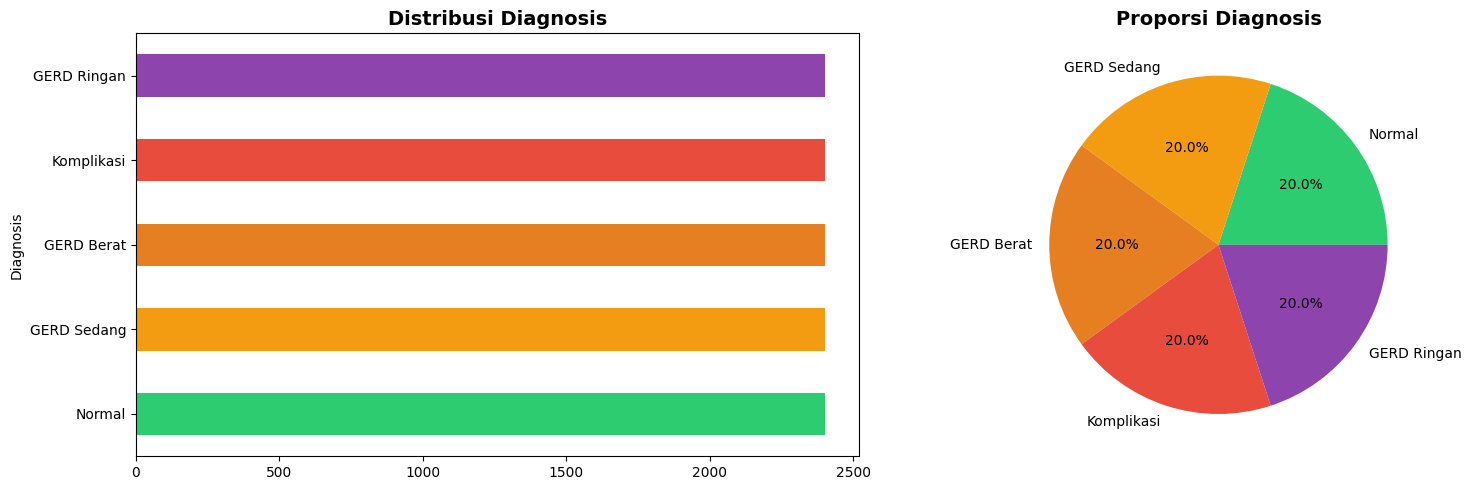

In [45]:
# 2.1 Distribusi Diagnosis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vc = df['Diagnosis'].value_counts()
colors = ['#2ecc71','#f39c12','#e67e22','#e74c3c','#8e44ad']
vc.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Diagnosis', fontsize=14, fontweight='bold')
vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Proporsi Diagnosis', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

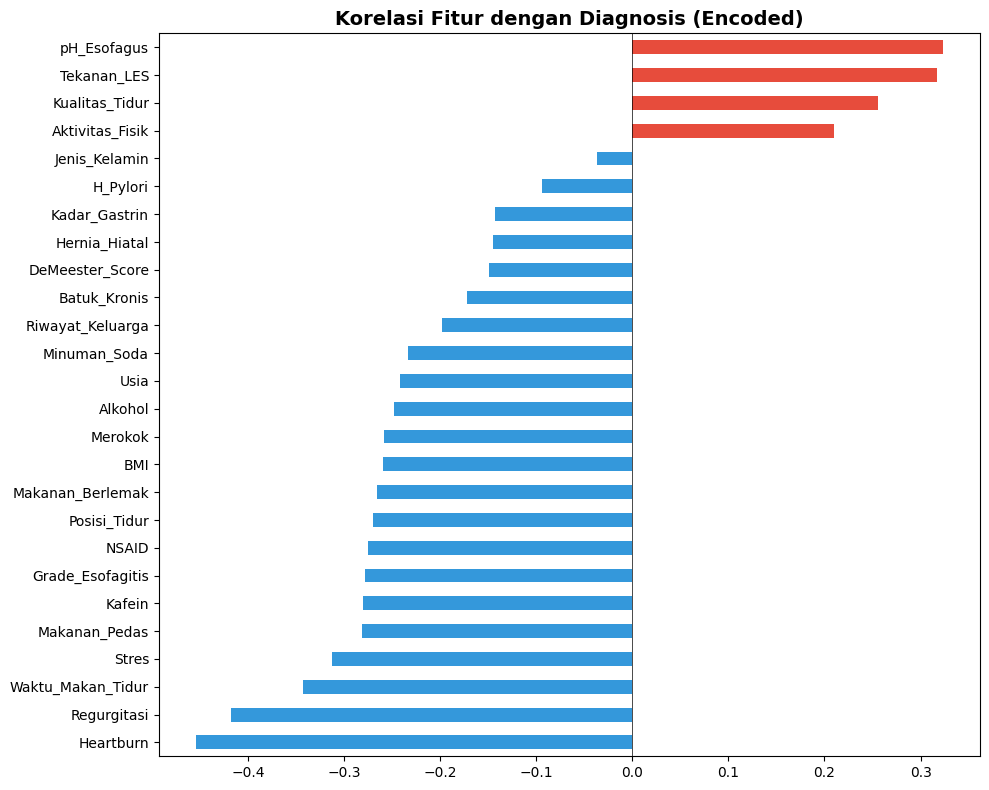

In [46]:
# 2.2 Korelasi fitur dengan skor risiko (proxy)
tier1_cols = ['Heartburn','Regurgitasi','Merokok','Alkohol','Waktu_Makan_Tidur',
              'NSAID','Stres','Riwayat_Keluarga','Kafein','Makanan_Pedas',
              'Makanan_Berlemak','Posisi_Tidur','Batuk_Kronis','Usia',
              'Jenis_Kelamin','Aktivitas_Fisik','Minuman_Soda','Kualitas_Tidur']
tier2_cols = ['BMI','pH_Esofagus','DeMeester_Score','Hernia_Hiatal',
              'Tekanan_LES','Grade_Esofagitis','H_Pylori','Kadar_Gastrin']
all_feature_cols = tier1_cols + tier2_cols

le_temp = LabelEncoder()
df['label_num'] = le_temp.fit_transform(df['Diagnosis'])
corr = df[all_feature_cols + ['label_num']].corr()['label_num'].drop('label_num').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corr.plot(kind='barh', ax=ax, color=['#e74c3c' if v>0 else '#3498db' for v in corr])
ax.set_title('Korelasi Fitur dengan Diagnosis (Encoded)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
df.drop('label_num', axis=1, inplace=True)

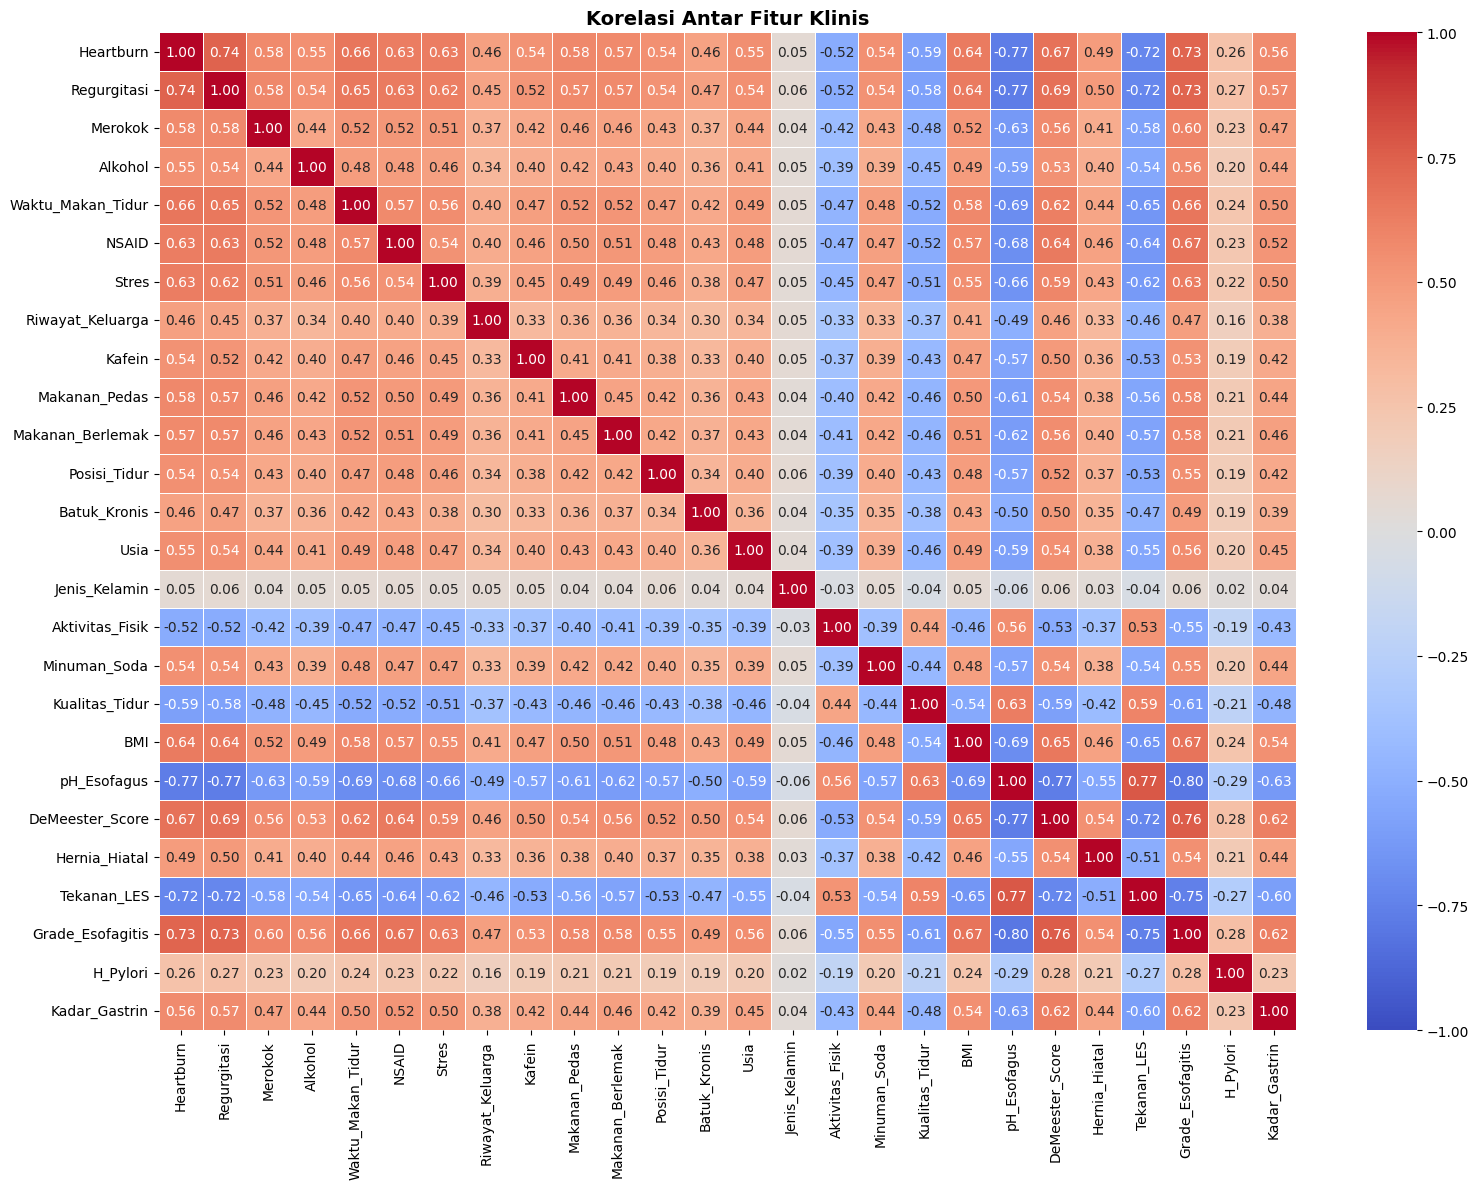

In [47]:
# 2.3 Heatmap korelasi antar fitur
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(df[all_feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, vmin=-1, vmax=1, center=0, linewidths=0.5)
ax.set_title('Korelasi Antar Fitur Klinis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

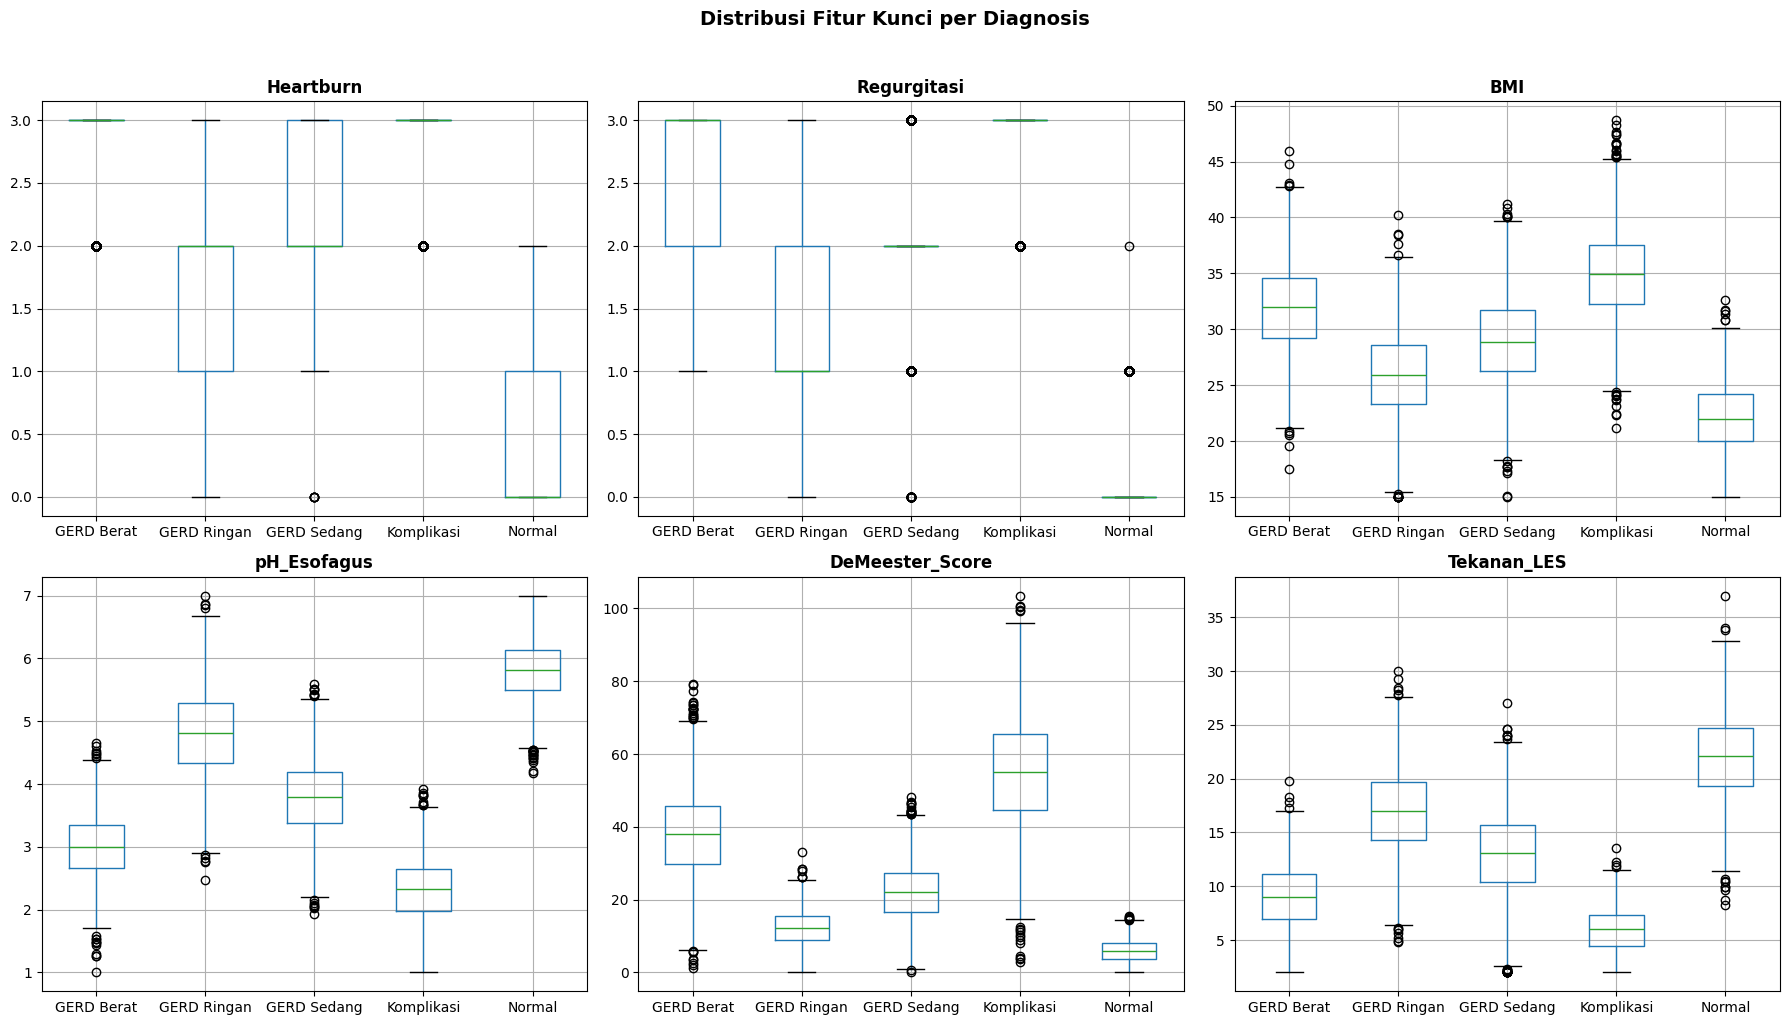

In [48]:
# 2.4 Boxplot fitur penting per diagnosis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_features = ['Heartburn','Regurgitasi','BMI','pH_Esofagus','DeMeester_Score','Tekanan_LES']
for ax, feat in zip(axes.flat, key_features):
    df.boxplot(column=feat, by='Diagnosis', ax=ax)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Distribusi Fitur Kunci per Diagnosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [49]:
# 3.1 Encode & Split
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Diagnosis'])
num_classes = len(le.classes_)
label_mapping = {int(v): str(k) for k, v in zip(le.classes_, le.transform(le.classes_))}
print(f"Kelas: {list(le.classes_)}")

X = df[all_feature_cols].values.astype(np.float32)
y = df['label_encoded'].values

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bal)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

Kelas: ['GERD Berat', 'GERD Ringan', 'GERD Sedang', 'Komplikasi', 'Normal']
Train: (8405, 26), Val: (1796, 26), Test: (1800, 26)


In [50]:
# 4.1 Deep Neural Network
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(X_train_s.shape[1], num_classes)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,853 (58.02 KB)

 Trainable params: 14,405 (56.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [51]:
my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history = model.fit(X_train_s, y_train_bal, validation_data=(X_val_s, y_val),
                    epochs=100, batch_size=64, callbacks=my_callbacks, verbose=1)

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5837 - loss: 1.0183 - val_accuracy: 0.5596 - val_loss: 0.9835 - learning_rate: 0.0010
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7732 - loss: 0.6069 - val_accuracy: 0.7500 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8159 - loss: 0.4882 - val_accuracy: 0.8775 - val_loss: 0.3456 - learning_rate: 0.0010
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8228 - loss: 0.4646 - val_accuracy: 0.9215 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 5/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8420 - loss: 0.4109 - val_accuracy: 0.9326 - val_loss: 0.2256 - learning_rate: 0.0010
Epoch 6/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8426 - loss: 0.4087 - val_accuracy: 0.9410 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 7/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8598 - loss: 0.

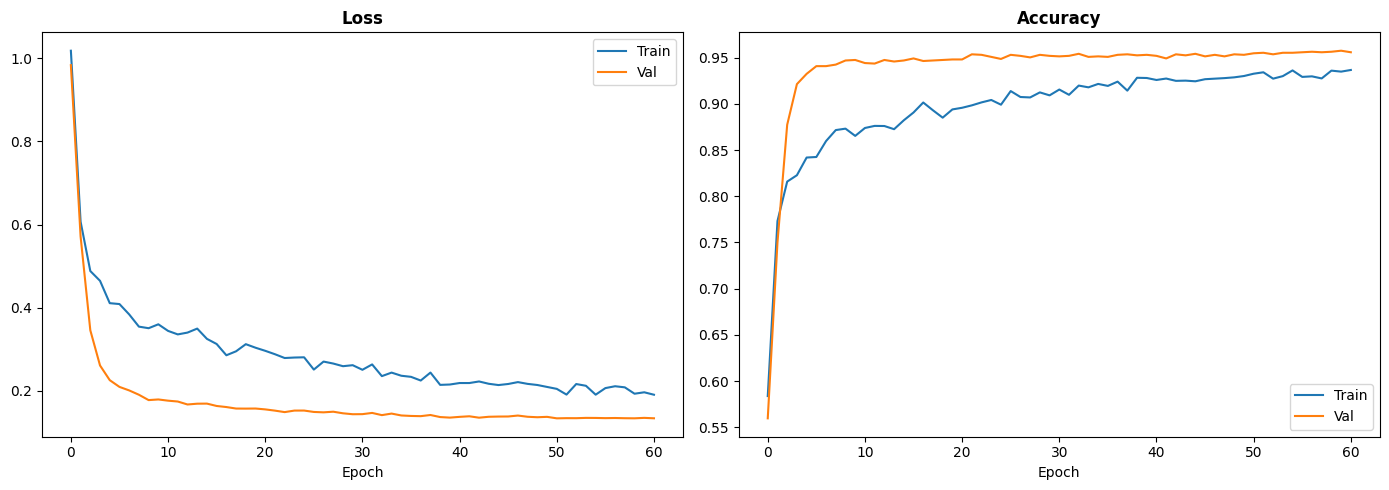

In [52]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train'); axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history.history['accuracy'], label='Train'); axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

In [53]:
# 4.2 Model Pembanding: XGBoost & Random Forest
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train_s, y_train_bal)
y_pred_xgb = xgb.predict(X_test_s)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train_s, y_train_bal)
y_pred_rf = rf.predict(X_test_s)

y_pred_nn = np.argmax(model.predict(X_test_s), axis=1)

print("=" * 50)
print("PERBANDINGAN MODEL")
print("=" * 50)
for name, yp in [('Neural Network', y_pred_nn), ('XGBoost', y_pred_xgb), ('Random Forest', y_pred_rf)]:
    acc = accuracy_score(y_test, yp)
    f1 = f1_score(y_test, yp, average='macro')
    print(f"  {name:20s} | Acc: {acc:.4f} | F1-Macro: {f1:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
PERBANDINGAN MODEL
  Neural Network       | Acc: 0.9433 | F1-Macro: 0.9430
  XGBoost              | Acc: 0.9328 | F1-Macro: 0.9325
  Random Forest        | Acc: 0.9311 | F1-Macro: 0.9308


In [54]:
# Pilih model terbaik
scores = {}
for name, yp in [('Neural Network', y_pred_nn), ('XGBoost', y_pred_xgb), ('Random Forest', y_pred_rf)]:
    scores[name] = f1_score(y_test, yp, average='macro')
best_name = max(scores, key=scores.get)
best_pred = {'Neural Network': y_pred_nn, 'XGBoost': y_pred_xgb, 'Random Forest': y_pred_rf}[best_name]
print(f"Model terbaik: {best_name} (F1-Macro: {scores[best_name]:.4f})\n")
print(classification_report(y_test, best_pred, target_names=le.classes_))

Model terbaik: Neural Network (F1-Macro: 0.9430)

              precision    recall  f1-score   support

  GERD Berat       0.92      0.87      0.89       360
 GERD Ringan       0.95      0.97      0.96       360
 GERD Sedang       0.94      0.93      0.93       360
  Komplikasi       0.92      0.94      0.93       360
      Normal       0.99      1.00      0.99       360

    accuracy                           0.94      1800
   macro avg       0.94      0.94      0.94      1800
weighted avg       0.94      0.94      0.94      1800



ANALISIS FALSE NEGATIVE (Kritis untuk Medis)
  GERD Berat      | TP: 314 | FN:  46 | FNR:0.128 | PERHATIAN
  GERD Ringan     | TP: 350 | FN:  10 | FNR:0.028 | Baik
  GERD Sedang     | TP: 335 | FN:  25 | FNR:0.069 | Baik
  Komplikasi      | TP: 340 | FN:  20 | FNR:0.056 | Baik
  Normal          | TP: 359 | FN:   1 | FNR:0.003 | Baik


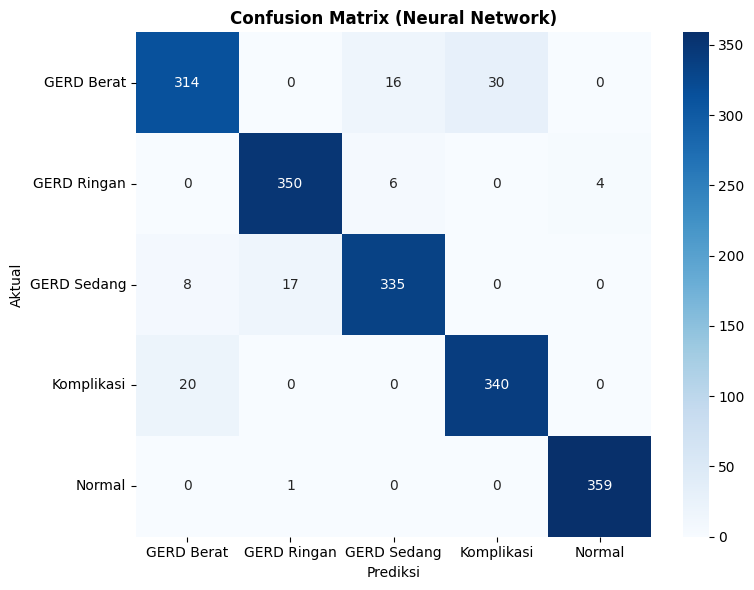

In [55]:
# Analisis False Negative per penyakit
cm = confusion_matrix(y_test, best_pred)
print("ANALISIS FALSE NEGATIVE (Kritis untuk Medis)")
print("=" * 65)
for i, disease in enumerate(le.classes_):
    tp = cm[i, i]; total = cm[i, :].sum()
    fn = total - tp; fnr = fn / total if total > 0 else 0
    status = 'PERHATIAN' if fnr > 0.1 else 'Baik'
    print(f"  {disease:15s} | TP:{tp:4d} | FN:{fn:4d} | FNR:{fnr:.3f} | {status}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title(f'Confusion Matrix ({best_name})', fontweight='bold')
plt.tight_layout(); plt.show()

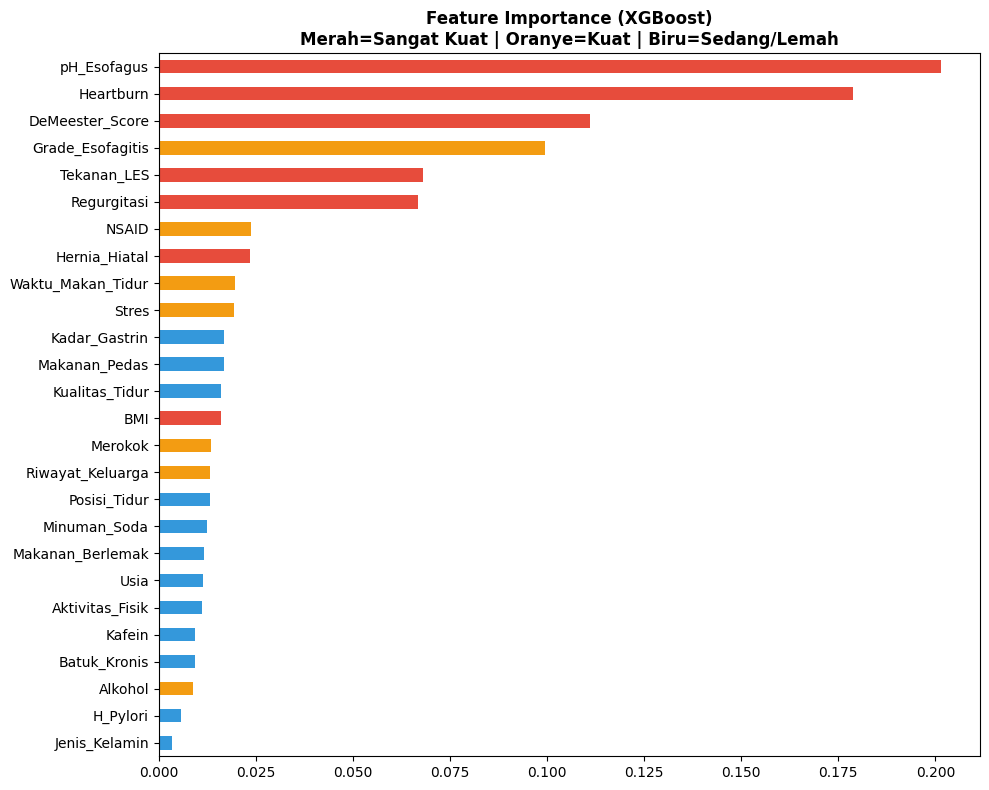

In [56]:
# Feature Importance (XGBoost)
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if f in ['Heartburn','Regurgitasi','BMI','pH_Esofagus','DeMeester_Score','Hernia_Hiatal','Tekanan_LES']
          else '#f39c12' if f in ['Merokok','Alkohol','Waktu_Makan_Tidur','NSAID','Stres','Riwayat_Keluarga','Grade_Esofagitis']
          else '#3498db' for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance (XGBoost)\nMerah=Sangat Kuat | Oranye=Kuat | Biru=Sedang/Lemah', fontweight='bold')
plt.tight_layout(); plt.show()

In [57]:
import json, os, pickle
os.makedirs('model_export', exist_ok=True)

# .keras (format terbaru)
model.save('model_export/model_aslam.keras')
print("Saved: model_aslam.keras")

# SavedModel (untuk konversi TFLite)
model.export('model_export/saved_model')
print("Saved: saved_model/")


Saved: model_aslam.keras
Saved artifact at 'model_export/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136521128798800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128801488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128788432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128792464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128789584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128797648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128793808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128793232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128802064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136521128794192: TensorSpec(shape=(), dtype=tf.resource, 

In [58]:
# .tflite
converter = tf.lite.TFLiteConverter.from_saved_model('model_export/saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('model_export/model_aslam.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"Saved: model_aslam.tflite ({len(tflite_model)/1024:.1f} KB)")


Saved: model_aslam.tflite (20.3 KB)


In [59]:
# .tfjs
!pip install -q tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model model_export/saved_model model_export/tfjs_model
print("Saved: tfjs_model/")
print("Files:", os.listdir('model_export/tfjs_model'))


2026-05-06 08:35:45.872400: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778056545.885286   10943 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778056545.889080   10943 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778056545.900026   10943 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778056545.900053   10943 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778056545.900057   10943 computation_placer.cc:177] computation placer alr

In [60]:
# Metadata & Preprocessing objects
metadata = {
    'label_mapping': label_mapping,
    'feature_names': all_feature_cols,
    'tier1_features': tier1_cols,
    'tier2_features': tier2_cols,
    'num_classes': num_classes,
    'diseases': list(le.classes_),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}
with open('model_export/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
with open('model_export/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('model_export/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
# XGBoost juga disimpan
with open('model_export/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
print("Semua metadata dan model tersimpan!")

Semua metadata dan model tersimpan!


In [61]:
# Download zip
!zip -r model_export.zip model_export/
from google.colab import files
files.download('model_export.zip')
files.download('dataset_aslam_clinical.csv')
print("Download selesai!")

updating: model_export/ (stored 0%)
updating: model_export/xgboost_model.pkl (deflated 67%)
updating: model_export/model_aslam.h5 (deflated 29%)
updating: model_export/model_aslam.keras (deflated 28%)
updating: model_export/model_aslam.tflite (deflated 19%)
updating: model_export/label_encoder.pkl (deflated 18%)
updating: model_export/metadata.json (deflated 62%)
updating: model_export/tfjs_model/ (stored 0%)
updating: model_export/tfjs_model/group1-shard1of1.bin (deflated 7%)
updating: model_export/tfjs_model/model.json (deflated 90%)
updating: model_export/scaler.pkl (deflated 8%)
updating: model_export/saved_model/ (stored 0%)
updating: model_export/saved_model/variables/ (stored 0%)
updating: model_export/saved_model/variables/variables.index (deflated 69%)
updating: model_export/saved_model/variables/variables.data-00000-of-00001 (deflated 10%)
updating: model_export/saved_model/assets/ (stored 0%)
updating: model_export/saved_model/fingerprint.pb (stored 0%)
updating: model_expor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download selesai!
